# OSM preprocessing pipeline

**Objective**
Prepare sampled OSM building footprints up to the cleaned, edge-aligned, artifact-filtered, hole-filtered, and vertex-balanced subset representation, while also persisting the retained working set and exporting one figure per preprocessed footprint for visual checking.

**Workflow overview**
1. Load the sampled metric building dataset from `data/interim/buildings_gdf.pkl`.
2. Remove clearly unsuitable shapes such as multipart footprints, wall-like strips, and over-holed plans.
3. Clean the remaining geometry through conservative normalization and multi-family edge alignment.
4. Derive geometric preprocessing metrics such as `area_m2`, `n_vertices`, and `complexity_class`.
5. Build the balanced working subset `subset_buildings_gdf` by exact exterior-vertex count.
6. Inspect representative retained examples and save the preprocessing outputs.

**Main artifacts written by this notebook**
- `data/interim/subset_buildings_gdf.pkl`
- `output/figures/osm_preprocessed/*.png`


### Configure notebook environment
Load the paths and helpers used for preprocessing the sampled local-metric OSM building dataset.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import colormaps as cmaps
from matplotlib.lines import Line2D


def find_project_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / '.git').exists() and (path / 'notebooks').exists():
            return path
    raise FileNotFoundError('Could not locate the ConvexDecomp project root.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
INTERIM_DIR = PROJECT_ROOT / 'data' / 'interim'
BUILDINGS_GDF_PATH = INTERIM_DIR / 'buildings_gdf.pkl'
SUBSET_BUILDINGS_PATH = INTERIM_DIR / 'subset_buildings_gdf.pkl'

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.helpers.GHSL_gridplot import GHSL_gridplot
from notebooks.helpers.osm_footprint_normalizer import (
    FootprintNormalizationConfig,
    LinearArtifactFilterConfig,
    annotate_linear_artifact_flags,
    count_exterior_vertices,
    count_polygon_holes,
    normalize_buildings_gdf,
)
from notebooks.helpers.polygon_edge_alignment import (
    EdgeAlignmentConfig,
    align_buildings_gdf,
    alignment_axis_records_for_polygon,
)
from notebooks.helpers.polygon_convexity import is_convex_polygon

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 10


### Load the sampled building dataset
Read `data/interim/buildings_gdf.pkl` created by `scripts/sample_osm_buildings.py`.

In [2]:
if not BUILDINGS_GDF_PATH.exists():
    raise FileNotFoundError(
        f'Missing {BUILDINGS_GDF_PATH}. Run scripts/sample_osm_buildings.py first to create the sampled building dataset.'
    )

buildings_gdf = pd.read_pickle(BUILDINGS_GDF_PATH)

print('buildings_gdf shape:', buildings_gdf.shape)
print('columns:', buildings_gdf.columns.tolist())
buildings_gdf.head()


buildings_gdf shape: (7140, 11)
columns: ['sample_id', 'city_key', 'osm_pbf', 'building_id', 'building', 'source_geom_type', 'lon', 'lat', 'offset_x', 'offset_y', 'geometry']


,sample_id,city_key,osm_pbf,building_id,building,source_geom_type,lon,lat,offset_x,offset_y,geometry
0,Galway_866073900,Galway,Galway.osm.pbf,866073900,house,Polygon,-9.048563,53.277671,-1.088853e+06,6.177334e+06,"POLYGON ((-5.05 2.34, -0.79 5.47, 5.01 -2.65, ..."
1,Galway_866089744,Galway,Galway.osm.pbf,866089744,shed,Polygon,-9.051675,53.276731,-1.089091e+06,6.177304e+06,"POLYGON ((2.31 -0.98, -0.4 -2.33, -2.38 0.7, 0..."
2,Galway_1018400708,Galway,Galway.osm.pbf,1018400708,house,Polygon,-9.043550,53.278861,-1.088482e+06,6.177346e+06,"POLYGON ((1.39 -5.92, -5.91 1.33, -1.52 5.8, 5..."
3,Galway_164864116,Galway,Galway.osm.pbf,164864116,retail,Polygon,-9.051562,53.273313,-1.089215e+06,6.176932e+06,"POLYGON ((-0.38 9.27, 6.65 -3, 8.47 -5.51, 0.9..."
4,Galway_866038351,Galway,Galway.osm.pbf,866038351,shed,Polygon,-9.045571,53.277948,-1.088648e+06,6.177294e+06,"POLYGON ((-0.75 6.08, 5.25 -3.04, 0.75 -6.08, ..."


## Remove weird shapes

### Keep only single-polygon buildings

**Inputs**
- Raw sampled `buildings_gdf` loaded from `data/interim/buildings_gdf.pkl`

**Steps**
1. Count geometry types before any filtering.
2. Collect the discarded non-`Polygon` rows for manual review.
3. Keep only `Polygon` buildings for the downstream preprocessing pipeline.
4. Preserve the retained single-polygon geometry as `geometry_raw` for later stage-by-stage comparisons.

**Outputs**
- Filtered `buildings_gdf`
- `discarded_multipolygon_gdf` for inspection


In [3]:
geom_counts_before = buildings_gdf.geom_type.value_counts(dropna=False)

discarded_multipolygon_gdf = buildings_gdf.loc[buildings_gdf.geom_type != 'Polygon'].copy().reset_index(drop=True)
discarded_multipolygon_gdf['n_polygon_parts'] = discarded_multipolygon_gdf.geometry.apply(
    lambda geom: len(list(getattr(geom, 'geoms', []))) if geom is not None and not getattr(geom, 'is_empty', True) else 0
)

buildings_gdf = buildings_gdf.loc[buildings_gdf.geom_type == 'Polygon'].copy().reset_index(drop=True)
buildings_gdf['geometry_raw'] = buildings_gdf.geometry.copy()

print('Geometry types before filtering:')
print(geom_counts_before.to_string())
print('Discarded non-Polygon rows:', len(discarded_multipolygon_gdf))
print('Rows after keeping Polygon only:', len(buildings_gdf))


Geometry types before filtering:
Polygon         7126
MultiPolygon      14
Discarded non-Polygon rows: 14
Rows after keeping Polygon only: 7126


### Plot discarded multipolygon buildings
Review a few discarded multipart footprints before the main preprocessing starts.


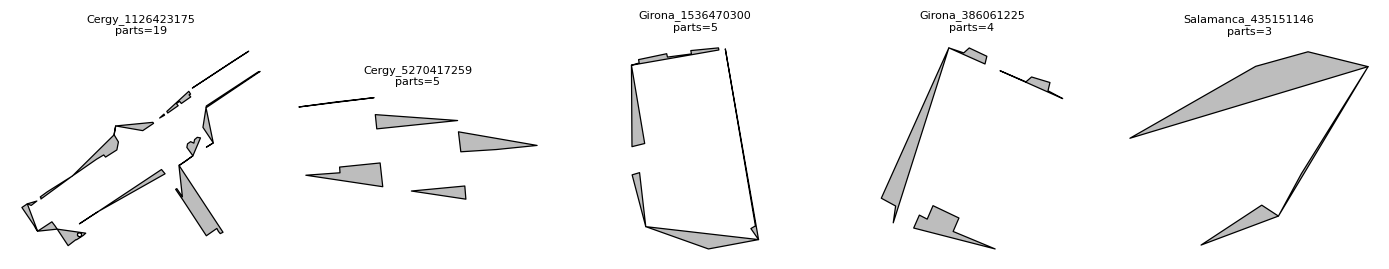

In [4]:
N_SHOW_MULTIPOLYGONS = 5
discarded_mp_plot_gdf = discarded_multipolygon_gdf.sort_values(['n_polygon_parts', 'sample_id'], ascending=[False, True]).head(N_SHOW_MULTIPOLYGONS).copy()

if discarded_mp_plot_gdf.empty:
    print('No discarded multipolygon buildings in the sampled dataset.')
else:
    plot_ids = discarded_mp_plot_gdf['sample_id'].tolist()
    GHSL_gridplot([{'name': 'discarded_multipolygons', 'gdf': discarded_mp_plot_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': '#bdbdbd', 'edgecolor': 'black', 'linewidth': 0.9}], ids=plot_ids, ncols=min(5, len(plot_ids)), figsize_scale=2.8, title_fn=lambda sid, i: f"{sid}\nparts={int(discarded_mp_plot_gdf.iloc[i]['n_polygon_parts'])}")


### Flag and remove obvious linear artifacts

**Inputs**
- Edge-aligned `buildings_gdf`

**Steps**
1. Configure conservative width and aspect-ratio thresholds for wall-like artifacts.
2. Flag hard-drop and review candidates.
3. Print the hard-drop candidates for inspection.
4. Remove only the hard-drop artifacts from `buildings_gdf`.

**Outputs**
- Filtered `buildings_gdf`
- `ARTIFACT_FILTER_CFG`
- `hard_drop_df` and `review_df`


In [5]:
ARTIFACT_FILTER_CFG = LinearArtifactFilterConfig(
    hard_min_width_m=2.0,
    hard_min_aspect_ratio=8.0,
    review_min_width_m=3.0,
    review_min_aspect_ratio=6.0,
)

buildings_gdf = annotate_linear_artifact_flags(buildings_gdf, geometry_col='geometry', cfg=ARTIFACT_FILTER_CFG)

hard_drop_df = buildings_gdf.loc[buildings_gdf['is_linear_artifact_hard']].copy()
review_df = buildings_gdf.loc[buildings_gdf['is_linear_artifact_review']].copy()

print('Linear-artifact summary:')
print(f"Hard-drop candidates: {len(hard_drop_df)}")
print(f"Review candidates: {len(review_df)}")

if not hard_drop_df.empty:
    print('Hard-drop candidates:')
    print(hard_drop_df[['sample_id', 'artifact_mrr_width_m', 'artifact_mrr_length_m', 'artifact_aspect_ratio', 'artifact_rect_fill']].sort_values(['artifact_mrr_width_m', 'artifact_aspect_ratio']).to_string(index=False))

buildings_gdf = buildings_gdf.loc[~buildings_gdf['is_linear_artifact_hard']].copy().reset_index(drop=True)
print('Rows after removing hard-drop linear artifacts:', len(buildings_gdf))


Linear-artifact summary:
Hard-drop candidates: 6
Review candidates: 11
Hard-drop candidates:
          sample_id  artifact_mrr_width_m  artifact_mrr_length_m  artifact_aspect_ratio  artifact_rect_fill
   Burgos_771723384              0.147979               8.809065              59.529334            0.928846
 Olomouc_1168533383              0.820127              12.973106              15.818411            0.909941
  Ostend_1117102632              1.091145             100.143561              91.778457            0.847906
  Treviso_138826079              1.269228              22.662371              17.855236            0.997367
    Forli_185690467              1.337092              11.621493               8.691616            0.610621
Wurzburg_1052846299              1.951029              19.175988               9.828655            0.980663
Rows after removing hard-drop linear artifacts: 7120


### Plot the hard-drop linear artifacts
Visualize the narrowest strip-like footprints that will be removed before the subset is built.

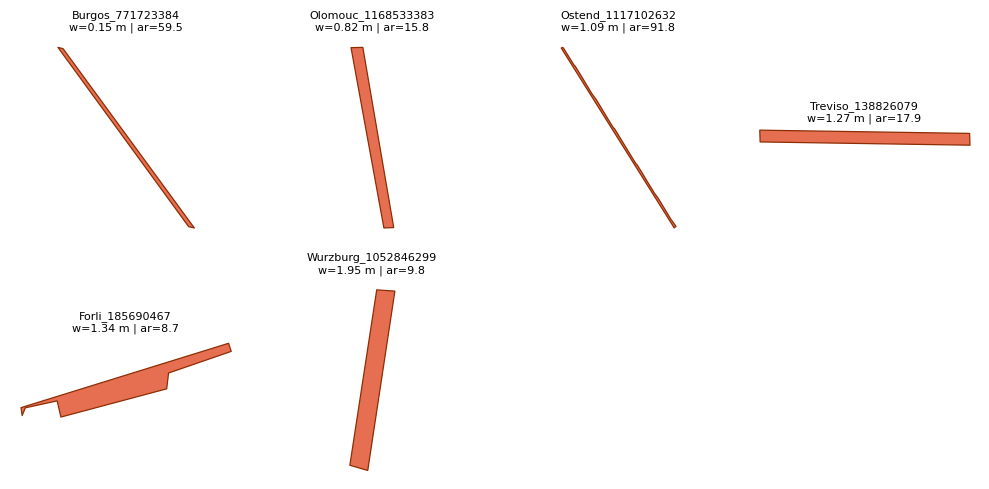

In [6]:
N_SHOW_ARTIFACTS = 12
artifact_plot_gdf = hard_drop_df.sort_values(['artifact_mrr_width_m', 'artifact_aspect_ratio']).head(N_SHOW_ARTIFACTS).copy()

if artifact_plot_gdf.empty:
    print('No hard-drop linear artifacts under the current thresholds.')
else:
    GHSL_gridplot([{'name': 'artifact_candidates', 'gdf': artifact_plot_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': '#e76f51', 'edgecolor': '#8c2d04', 'linewidth': 0.9}], ids=artifact_plot_gdf['sample_id'].tolist(), ncols=4, figsize_scale=2.5, title_fn=lambda sid, i: f"{sid}\nw={artifact_plot_gdf.iloc[i]['artifact_mrr_width_m']:.2f} m | ar={artifact_plot_gdf.iloc[i]['artifact_aspect_ratio']:.1f}")


### Count holes and remove over-holed footprints

**Inputs**
- Artifact-filtered `buildings_gdf`

**Steps**
1. Set the maximum allowed hole count.
2. Count holes for each retained polygon.
3. Collect the over-holed buildings for review.
4. Remove footprints with more than `MAX_ALLOWED_HOLES` holes before subset sampling.

**Outputs**
- Updated `buildings_gdf` with `n_holes`
- `too_many_holes_df`
- `MAX_ALLOWED_HOLES`


In [7]:
MAX_ALLOWED_HOLES = 4

buildings_gdf['n_holes'] = buildings_gdf.geometry.apply(count_polygon_holes)
too_many_holes_df = buildings_gdf.loc[buildings_gdf['n_holes'] > MAX_ALLOWED_HOLES].copy()

print('Excessive-hole summary:')
print(f"Removed candidates (> {MAX_ALLOWED_HOLES} holes): {len(too_many_holes_df)}")

if not too_many_holes_df.empty:
    print('Removed excessive-hole candidates:')
    print(too_many_holes_df[['sample_id', 'n_holes']].sort_values(['n_holes', 'sample_id'], ascending=[False, True]).to_string(index=False))

buildings_gdf = buildings_gdf.loc[buildings_gdf['n_holes'] <= MAX_ALLOWED_HOLES].copy().reset_index(drop=True)
print('Rows after removing excessive-hole buildings:', len(buildings_gdf))


Excessive-hole summary:
Removed candidates (> 4 holes): 3
Removed excessive-hole candidates:
                   sample_id  n_holes
           Blackpool_3741587        9
Mairena_del_Aljarafe_4148233        6
           Sassari_562068877        6
Rows after removing excessive-hole buildings: 7117


### Plot discarded excessive-hole buildings
Review a few removed footprints with many atriums or internal courtyards.


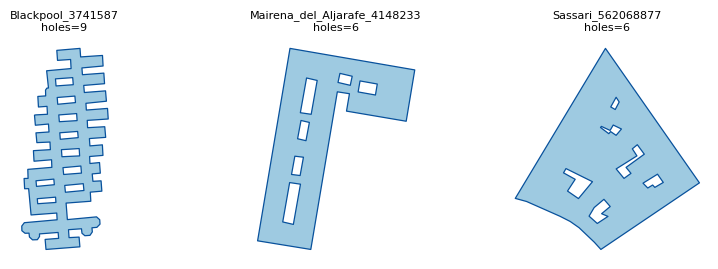

In [8]:
N_SHOW_HOLES = 5
too_many_holes_plot_gdf = too_many_holes_df.sort_values(['n_holes', 'sample_id'], ascending=[False, True]).head(N_SHOW_HOLES).copy()

if too_many_holes_plot_gdf.empty:
    print('No excessive-hole buildings under the current threshold.')
else:
    plot_ids = too_many_holes_plot_gdf['sample_id'].tolist()
    GHSL_gridplot([{'name': 'too_many_holes', 'gdf': too_many_holes_plot_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': '#9ecae1', 'edgecolor': '#08519c', 'linewidth': 0.9}], ids=plot_ids, ncols=min(5, len(plot_ids)), figsize_scale=2.8, title_fn=lambda sid, i: f"{sid}\nholes={int(too_many_holes_plot_gdf.iloc[i]['n_holes'])}")


## Geometry cleaning

### Normalize footprint geometries

**Inputs**
- Single-polygon `buildings_gdf`

**Steps**
1. Configure a conservative footprint normalizer with simplification, snapping, short-edge cleanup, and almost-collinear cleanup thresholds.
2. Apply the normalizer to each retained polygon.
3. Record vertex and area deltas so the strongest simplifications can be inspected in the next cell.

**Outputs**
- Normalized `buildings_gdf`
- `NORMALIZATION_CFG`
- Diagnostic columns such as `geometry_before_norm`, `n_vertices_before_norm`, `n_vertices_after_norm`, and `area_delta_norm_m2`


In [9]:
NORMALIZATION_CFG = FootprintNormalizationConfig(
    simplify_tolerance_m=0.2,
    snap_tolerance_m=0.05,
    min_edge_length_m=0.75,
    collinear_distance_tol_m=0.3,
    collinear_angle_tol_deg=10.0,
    area_change_ratio_tol=0.03,
    area_change_m2_tol=3.0,
    max_passes=8,
)

buildings_gdf = normalize_buildings_gdf(buildings_gdf, geometry_col='geometry', cfg=NORMALIZATION_CFG)

n_changed = int((buildings_gdf['vertex_delta_norm'] != 0).sum())
mean_vertex_delta = float(buildings_gdf['vertex_delta_norm'].mean())
max_area_delta = float(buildings_gdf['area_delta_norm_m2'].abs().max())

print('Normalization summary:')
print(f'Changed footprints: {n_changed} / {len(buildings_gdf)}')
print(f'Mean vertex delta: {mean_vertex_delta:.2f}')
print(f'Max absolute area delta: {max_area_delta:.3f} m²')

buildings_gdf[['sample_id', 'n_vertices_before_norm', 'n_vertices_after_norm', 'vertex_delta_norm', 'area_delta_norm_m2']].sort_values(['vertex_delta_norm', 'area_delta_norm_m2']).head(10)


Normalization summary:
Changed footprints: 2067 / 7117
Mean vertex delta: -0.62
Max absolute area delta: 20.103 m²


,sample_id,n_vertices_before_norm,n_vertices_after_norm,vertex_delta_norm,area_delta_norm_m2
1691,Brussels_239895036,113,65,-48,7.33350
1702,Alphen_aan_den_Rijn_289376919,60,24,-36,-20.10305
4285,Venice_138843884,93,68,-25,4.63655
4417,Warsaw_144913593,33,14,-19,-4.49015
2094,Wroclaw_1033840320,153,134,-19,9.77235
1432,Antwerp_181181131,67,49,-18,-0.45135
5712,Lleida_756173186,31,14,-17,-8.89840
2489,Munster_142169350,20,4,-16,1.14835
5555,Caserta_171145692,21,6,-15,-9.99550
3378,Paris_62377968,63,48,-15,0.02650


### Plot the strongest footprint simplifications
Overlay the normalized footprints on top of their original geometry for the buildings with the largest vertex reductions.

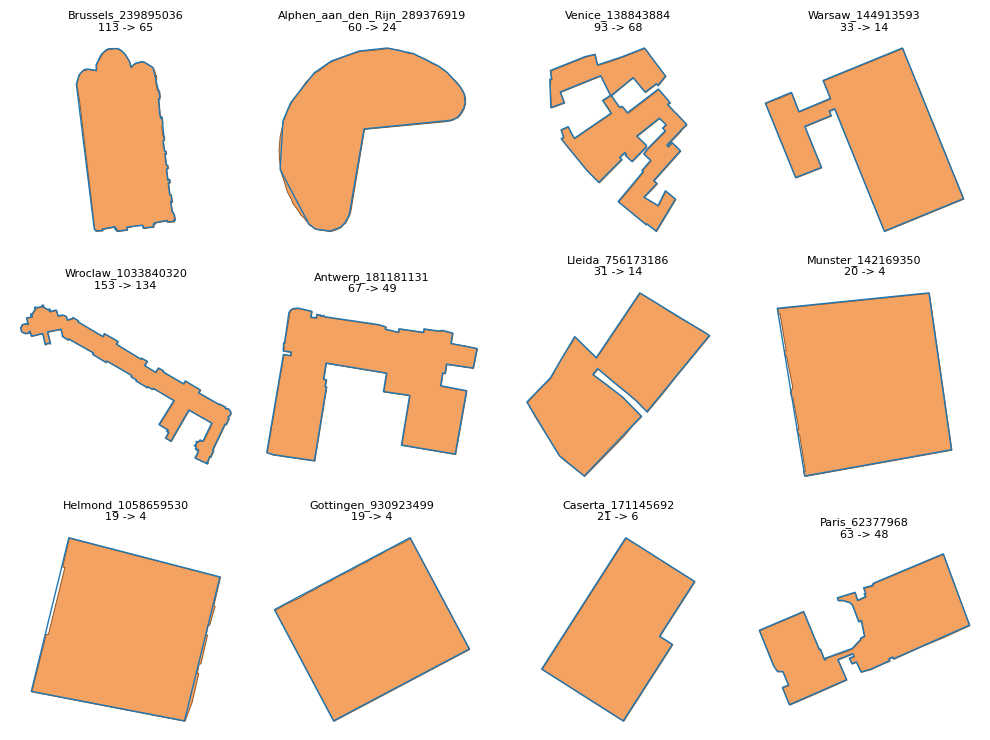

In [10]:
N_SHOW_NORM = 12
changed_plot_gdf = buildings_gdf.loc[buildings_gdf['vertex_delta_norm'] < 0].copy().sort_values(['vertex_delta_norm', 'n_vertices_before_norm', 'area_before_norm_m2']).head(N_SHOW_NORM)

if changed_plot_gdf.empty:
    print('No buildings were simplified under the current normalization settings.')
else:
    before_gdf = gpd.GeoDataFrame(changed_plot_gdf.copy(), geometry='geometry_before_norm', crs=buildings_gdf.crs)
    after_gdf = gpd.GeoDataFrame(changed_plot_gdf.copy(), geometry='geometry', crs=buildings_gdf.crs)
    plot_ids = changed_plot_gdf['sample_id'].tolist()
    GHSL_gridplot([
        {'name': 'before_norm', 'gdf': before_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry_before_norm', 'color': '#f4a261', 'edgecolor': '#8d5524', 'linewidth': 0.7},
        {'name': 'after_norm', 'gdf': after_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': 'none', 'edgecolor': '#1f77b4', 'linewidth': 1.0, 'zorder': 3},
    ], ids=plot_ids, ncols=4, figsize_scale=2.5, title_fn=lambda sid, i: f"{sid}\n{int(changed_plot_gdf.iloc[i]['n_vertices_before_norm'])} -> {int(changed_plot_gdf.iloc[i]['n_vertices_after_norm'])}")


### Apply conservative edge alignment

**Inputs**
- Normalized `buildings_gdf`

**Steps**
1. Configure a conservative multi-family edge aligner.
2. Preserve the pre-alignment geometry in `geometry_before_align`.
3. Align nearly colinear edges within small angle families.
4. Record vertex, area, and angle-family diagnostics for inspection.

**Outputs**
- Edge-aligned `buildings_gdf`
- `EDGE_ALIGNMENT_CFG`
- Diagnostic columns such as `vertex_delta_align`, `area_delta_align_m2`, and `n_angle_families_align`


In [11]:
EDGE_ALIGNMENT_CFG = EdgeAlignmentConfig(
    use_angle_families=True,
    family_angle_tol_deg=3.0,
    line_angle_tol_deg=2.0,
    line_offset_tol_m=0.2,
    collinear_tol_deg=1.0,
    min_seg_len_m=0.05,
    max_vertex_snap_shift_m=0.4,
    align_min_area_ratio=0.97,
    align_max_area_ratio=1.03,
    align_max_edge_stretch=2.0,
    align_max_hausdorff_m=0.5,
)

buildings_gdf['geometry_before_align'] = buildings_gdf.geometry.copy()
buildings_gdf['area_before_align_m2'] = buildings_gdf.geometry.area.astype(float)
buildings_gdf = align_buildings_gdf(buildings_gdf, geometry_col='geometry', cfg=EDGE_ALIGNMENT_CFG)

n_align_changed = int(buildings_gdf['alignment_changed'].sum())
mean_align_vertex_delta = float(buildings_gdf['vertex_delta_align'].mean())
max_align_area_delta = float(buildings_gdf['area_delta_align_m2'].abs().max())
mean_angle_families = float(buildings_gdf['n_angle_families_align'].mean())
max_angle_families = int(buildings_gdf['n_angle_families_align'].max())

print('Edge-alignment summary:')
print(f'Changed footprints: {n_align_changed} / {len(buildings_gdf)}')
print(f'Mean vertex delta: {mean_align_vertex_delta:.2f}')
print(f'Max absolute area delta: {max_align_area_delta:.3f} m²')
print(f'Mean detected angle families: {mean_angle_families:.2f}')
print(f'Max detected angle families: {max_angle_families}')

buildings_gdf[['sample_id', 'n_angle_families_align', 'n_vertices_before_align', 'n_vertices_after_align', 'vertex_delta_align', 'area_delta_align_m2']].sort_values(['vertex_delta_align', 'area_delta_align_m2']).head(10)


Edge-alignment summary:
Changed footprints: 3003 / 7117
Mean vertex delta: -0.00
Max absolute area delta: 26.620 m²
Mean detected angle families: 2.94
Max detected angle families: 28


,sample_id,n_angle_families_align,n_vertices_before_align,n_vertices_after_align,vertex_delta_align,area_delta_align_m2
1895,Badajoz_717196752,3,14,13,-1,-0.054271
3706,Pabianice_441787672,6,12,11,-1,-0.007774
5262,Metz_49807089,7,11,10,-1,1.018801
1584,Dordrecht_273479649,6,26,25,-1,3.068829
1472,Linkoping_8008896,14,36,35,-1,4.683335
738,Alessandria_89386593,4,22,21,-1,5.174454
4241,Burgos_51180063,5,15,15,0,-26.619622
2010,Cadiz_256278979,2,6,6,0,-26.193431
6099,Sunderland_65615038,15,95,95,0,-18.313177
5881,Foggia_267244175,8,20,20,0,-13.269585


### Apply a final geometry sanity filter

**Inputs**
- `buildings_gdf` after edge alignment and earlier artifact / hole filtering
- Existing threshold `MAX_ALLOWED_HOLES`
- Shared helpers `count_polygon_holes` and `is_convex_polygon`

**Steps**
1. Recount holes on the post-alignment geometry in case preprocessing changed the ring structure.
2. Drop any rows whose geometry is no longer a single `Polygon`.
3. Keep holed footprints when they still satisfy `MAX_ALLOWED_HOLES`.
4. Drop footprints that became convex, since they no longer need convex postprocessing.
5. Drop footprints whose cleaned area is smaller than `2.0 m^2`.

**Outputs**
- Updated `buildings_gdf`
- `final_discarded_multipart_df`, `final_too_many_holes_df`, `final_already_convex_df`, and `final_too_small_df`

In [12]:
FINAL_MIN_AREA_M2 = 2.0

buildings_gdf['n_holes'] = buildings_gdf.geometry.apply(count_polygon_holes)
buildings_gdf['area_m2'] = buildings_gdf.geometry.area.astype(float)
buildings_gdf['is_convex'] = buildings_gdf.geometry.apply(is_convex_polygon)

final_discarded_multipart_df = buildings_gdf.loc[buildings_gdf.geom_type != 'Polygon'].copy().reset_index(drop=True)
final_too_many_holes_df = buildings_gdf.loc[
    (buildings_gdf.geom_type == 'Polygon') & (buildings_gdf['n_holes'] > MAX_ALLOWED_HOLES)
].copy().reset_index(drop=True)
final_already_convex_df = buildings_gdf.loc[
    (buildings_gdf.geom_type == 'Polygon')
    & (buildings_gdf['n_holes'] <= MAX_ALLOWED_HOLES)
    & buildings_gdf['is_convex']
].copy().reset_index(drop=True)
final_too_small_df = buildings_gdf.loc[
    (buildings_gdf.geom_type == 'Polygon')
    & (buildings_gdf['n_holes'] <= MAX_ALLOWED_HOLES)
    & (~buildings_gdf['is_convex'])
    & (buildings_gdf['area_m2'] < FINAL_MIN_AREA_M2)
].copy().reset_index(drop=True)

keep_mask = (
    (buildings_gdf.geom_type == 'Polygon')
    & (buildings_gdf['n_holes'] <= MAX_ALLOWED_HOLES)
    & (~buildings_gdf['is_convex'])
    & (buildings_gdf['area_m2'] >= FINAL_MIN_AREA_M2)
)
buildings_gdf = buildings_gdf.loc[keep_mask].copy().reset_index(drop=True)

print('Final geometry sanity filter:')
print(f"Removed multipart rows after preprocessing: {len(final_discarded_multipart_df)}")
print(f"Removed rows with > {MAX_ALLOWED_HOLES} holes after preprocessing: {len(final_too_many_holes_df)}")
print(f"Removed already-convex rows after preprocessing: {len(final_already_convex_df)}")
print(f"Removed rows with area < {FINAL_MIN_AREA_M2:.1f} m^2 after preprocessing: {len(final_too_small_df)}")
print(f"Rows retained after final geometry sanity filter: {len(buildings_gdf)}")

Final geometry sanity filter:
Removed multipart rows after preprocessing: 2
Removed rows with > 4 holes after preprocessing: 0
Removed already-convex rows after preprocessing: 4220
Removed rows with area < 2.0 m^2 after preprocessing: 0
Rows retained after final geometry sanity filter: 2895


### Plot edge-aligned footprints with raw and family-colored axes
Overlay the aligned footprints on top of their pre-alignment geometry twice: first with all inferred axes shown in dashed black before grouping, then with the same axes colored by their matched angle families.


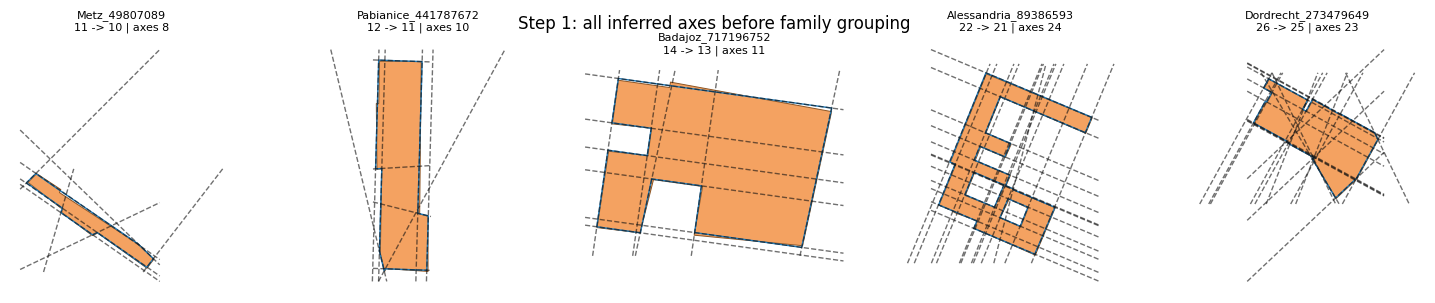

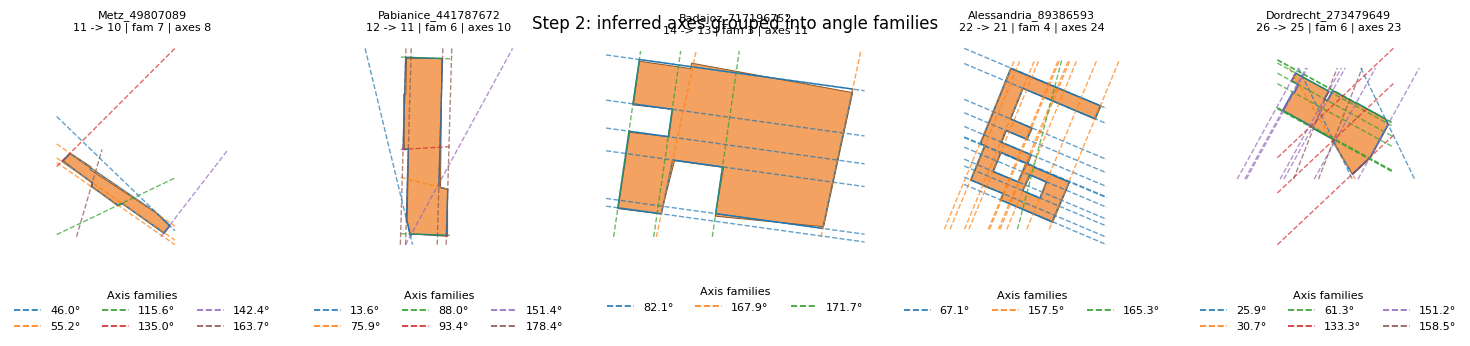

In [13]:
N_SHOW_ALIGN = 5
aligned_plot_gdf = buildings_gdf.loc[buildings_gdf['vertex_delta_align'] < 0].copy().sort_values(
    ['vertex_delta_align', 'n_vertices_before_align', 'area_before_align_m2']
).head(N_SHOW_ALIGN)

if aligned_plot_gdf.empty:
    print('No buildings changed under the current edge-alignment settings.')
else:
    axis_rows = []
    axis_count_by_id = {}
    family_info_by_id = {}
    for _, row in aligned_plot_gdf.iterrows():
        axis_records, axis_diag = alignment_axis_records_for_polygon(row.geometry, EDGE_ALIGNMENT_CFG)
        axis_count_by_id[row['sample_id']] = axis_diag['n_axes']
        family_lookup = {}
        for axis_idx, record in enumerate(axis_records):
            label = f"{record['family_angle_deg']:.1f}°"
            family_lookup[label] = float(record['family_angle_deg'])
            axis_rows.append({
                'sample_id': row['sample_id'],
                'axis_idx': axis_idx,
                'family_label': label,
                'family_angle_deg': float(record['family_angle_deg']),
                'geometry': record['geometry'],
            })
        family_info_by_id[row['sample_id']] = sorted(family_lookup.items(), key=lambda item: item[1])

    before_align_gdf = gpd.GeoDataFrame(aligned_plot_gdf.copy(), geometry='geometry_before_align', crs=buildings_gdf.crs)
    after_align_gdf = gpd.GeoDataFrame(aligned_plot_gdf.copy(), geometry='geometry', crs=buildings_gdf.crs)
    axes_gdf = gpd.GeoDataFrame(axis_rows, geometry='geometry', crs=buildings_gdf.crs) if axis_rows else gpd.GeoDataFrame(
        columns=['sample_id', 'axis_idx', 'family_label', 'family_angle_deg', 'geometry'], geometry='geometry', crs=buildings_gdf.crs
    )
    plot_ids = aligned_plot_gdf['sample_id'].tolist()
    plot_sources = [
        {'name': 'before_align', 'gdf': before_align_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry_before_align', 'color': '#f4a261', 'edgecolor': '#8d5524', 'linewidth': 0.7},
        {'name': 'after_align', 'gdf': after_align_gdf, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': 'none', 'edgecolor': '#1f77b4', 'linewidth': 1.0, 'zorder': 3},
    ]

    fig_black, axes_black = GHSL_gridplot(
        plot_sources,
        ids=plot_ids,
        ncols=min(5, len(plot_ids)),
        figsize_scale=3.0,
        title_fn=lambda sid, i: f"{sid}\n{int(aligned_plot_gdf.iloc[i]['n_vertices_before_align'])} -> {int(aligned_plot_gdf.iloc[i]['n_vertices_after_align'])} | axes {int(axis_count_by_id.get(sid, 0))}",
    )
    axes_black = np.atleast_1d(axes_black).ravel()
    for i, sid in enumerate(plot_ids):
        ax = axes_black[i]
        sample_axes = axes_gdf.loc[axes_gdf['sample_id'] == sid].copy() if not axes_gdf.empty else gpd.GeoDataFrame(columns=axes_gdf.columns, geometry='geometry', crs=buildings_gdf.crs)
        if sample_axes.empty:
            continue
        sample_axes.plot(ax=ax, color='#111111', linewidth=1.0, linestyle='--', alpha=0.6, zorder=10)
    fig_black.suptitle('Step 1: all inferred axes before family grouping', y=0.98)
    fig_black.subplots_adjust(top=0.90, hspace=0.45)

    fig_color, axes_color = GHSL_gridplot(
        plot_sources,
        ids=plot_ids,
        ncols=min(5, len(plot_ids)),
        figsize_scale=3.0,
        title_fn=lambda sid, i: f"{sid}\n{int(aligned_plot_gdf.iloc[i]['n_vertices_before_align'])} -> {int(aligned_plot_gdf.iloc[i]['n_vertices_after_align'])} | fam {int(aligned_plot_gdf.iloc[i]['n_angle_families_align'])} | axes {int(axis_count_by_id.get(sid, 0))}",
    )
    axes_color = np.atleast_1d(axes_color).ravel()
    for i, sid in enumerate(plot_ids):
        ax = axes_color[i]
        sample_axes = axes_gdf.loc[axes_gdf['sample_id'] == sid].copy() if not axes_gdf.empty else gpd.GeoDataFrame(columns=axes_gdf.columns, geometry='geometry', crs=buildings_gdf.crs)
        family_info = family_info_by_id.get(sid, [])
        if sample_axes.empty or not family_info:
            continue
        family_colors = {label: tuple(cmaps['tab10'](idx % 10)) for idx, (label, _) in enumerate(family_info)}
        legend_handles = []
        for label, _ in family_info:
            family_axes = sample_axes.loc[sample_axes['family_label'] == label]
            if family_axes.empty:
                continue
            family_axes.plot(ax=ax, color=family_colors[label], linewidth=1.0, linestyle='--', alpha=0.7, zorder=10)
            legend_handles.append(Line2D([0], [0], color=family_colors[label], linestyle='--', linewidth=1.2, label=label))
        if legend_handles:
            ax.legend(
                handles=legend_handles,
                title='Axis families',
                loc='upper center',
                bbox_to_anchor=(0.5, -0.12),
                ncol=min(3, len(legend_handles)),
                frameon=False,
                fontsize=8,
                title_fontsize=8,
                handlelength=2.4,
            )
    fig_color.suptitle('Step 2: inferred axes grouped into angle families', y=0.98)
    fig_color.subplots_adjust(top=0.90, bottom=0.18, hspace=0.5)


## Derive preprocessing metrics

### Compute footprint area, vertex count, and complexity class

**Inputs**
- `buildings_gdf` after normalization, edge alignment, artifact removal, hole filtering, and the final geometry sanity filter

**Steps**
1. Compute `area_m2` from the cleaned local-metric geometry.
2. Count exterior vertices for each footprint.
3. Map the cleaned vertex counts into complexity classes `A-D` for inspection only.

**Outputs**
- Updated `buildings_gdf` with `area_m2`, `n_vertices`, and `complexity_class`


In [14]:
COMPLEXITY_CLASSES = {
    'A': (5, 7),
    'B': (8, 12),
    'C': (13, 18),
    'D': (19, None),
}


def assign_complexity_class(n_vertices: int):
    if n_vertices is None or n_vertices < 5:
        return None
    for cls, (vmin, vmax) in COMPLEXITY_CLASSES.items():
        if n_vertices < vmin:
            continue
        if vmax is None or n_vertices <= vmax:
            return cls
    return None


buildings_gdf['area_m2'] = buildings_gdf.geometry.area.astype(float)
buildings_gdf['n_vertices'] = buildings_gdf.geometry.apply(count_exterior_vertices)
buildings_gdf['complexity_class'] = buildings_gdf['n_vertices'].apply(assign_complexity_class)

print('Complexity counts:')
print(buildings_gdf['complexity_class'].value_counts(dropna=False).sort_index().to_string())
print('Vertex count summary:')
print(buildings_gdf['n_vertices'].describe().to_string())

buildings_gdf[['sample_id', 'area_m2', 'n_vertices', 'complexity_class']].head()


Complexity counts:
complexity_class
A       1184
B       1230
C        278
D        187
None      16
Vertex count summary:
count    2895.000000
mean        9.822453
std         7.000956
min         4.000000
25%         6.000000
50%         8.000000
75%        11.000000
max       134.000000


,sample_id,area_m2,n_vertices,complexity_class
0,Derry_Londonderry_1047720035,258.534715,16,C
1,Derry_Londonderry_1043578950,57.848245,6,A
2,Derry_Londonderry_685440945,64.836688,6,A
3,Brest_42536053,119.711612,13,C
4,Brest_42538440,106.032904,6,A


## Build the working OSM subset

### Sample a bounded subset by exact exterior-vertex count

**Inputs**
- `buildings_gdf` with derived `area_m2`, `n_vertices`, and `n_holes`
- Target sampling parameters `TARGET_PER_VERTEX`, `VERTEX_MIN`, `VERTEX_MAX`

**Steps**
1. Group the retained cleaned buildings by `n_vertices`.
2. Sample up to `TARGET_PER_VERTEX` buildings from each exact vertex-count bucket.
3. Keep the downstream columns needed for decomposition.
4. Record how many buildings were available and selected per bucket.

**Outputs**
- `subset_buildings_gdf`
- `subset_counts_df`


In [23]:
TARGET_PER_VERTEX = 1000
VERTEX_MIN = 6
VERTEX_MAX = 32
SUBSET_RANDOM_SEED = 123

keep_cols = ['sample_id', 'geometry', 'area_m2', 'n_vertices', 'n_holes', 'complexity_class']
missing_cols = [col for col in keep_cols if col not in buildings_gdf.columns]
if missing_cols:
    raise KeyError(f'Missing expected columns in buildings_gdf: {missing_cols}')

subset_parts = []
subset_counts = []

for n_vertices in range(VERTEX_MIN, VERTEX_MAX + 1):
    g_sub = buildings_gdf.loc[buildings_gdf['n_vertices'] == n_vertices]
    n_available = len(g_sub)
    if n_available == 0:
        subset_counts.append({'n_vertices': n_vertices, 'n_selected': 0, 'n_available': 0})
        continue

    n_take = min(TARGET_PER_VERTEX, n_available)
    sampled = g_sub.sample(n=n_take, replace=False, random_state=SUBSET_RANDOM_SEED + n_vertices)
    subset_parts.append(sampled)
    subset_counts.append({'n_vertices': n_vertices, 'n_selected': n_take, 'n_available': n_available})

subset_buildings_gdf = gpd.GeoDataFrame(pd.concat(subset_parts, ignore_index=True), geometry='geometry', crs=buildings_gdf.crs)[keep_cols].copy()
subset_counts_df = pd.DataFrame(subset_counts)

print('subset_buildings_gdf shape:', subset_buildings_gdf.shape)
print('CRS:', subset_buildings_gdf.crs)
subset_counts_df


subset_buildings_gdf shape: (2756, 6)
CRS: EPSG:32633


,n_vertices,n_selected,n_available
0,6,976,976
1,7,134,134
2,8,598,598
3,9,127,127
4,10,232,232
5,11,65,65
6,12,208,208
7,13,50,50
8,14,82,82
9,15,27,27


## Inspection and saving


### Plot the working subset by vertex count
Inspect one retained example from a sequence of vertex-count buckets that will be written to the downstream pickle.


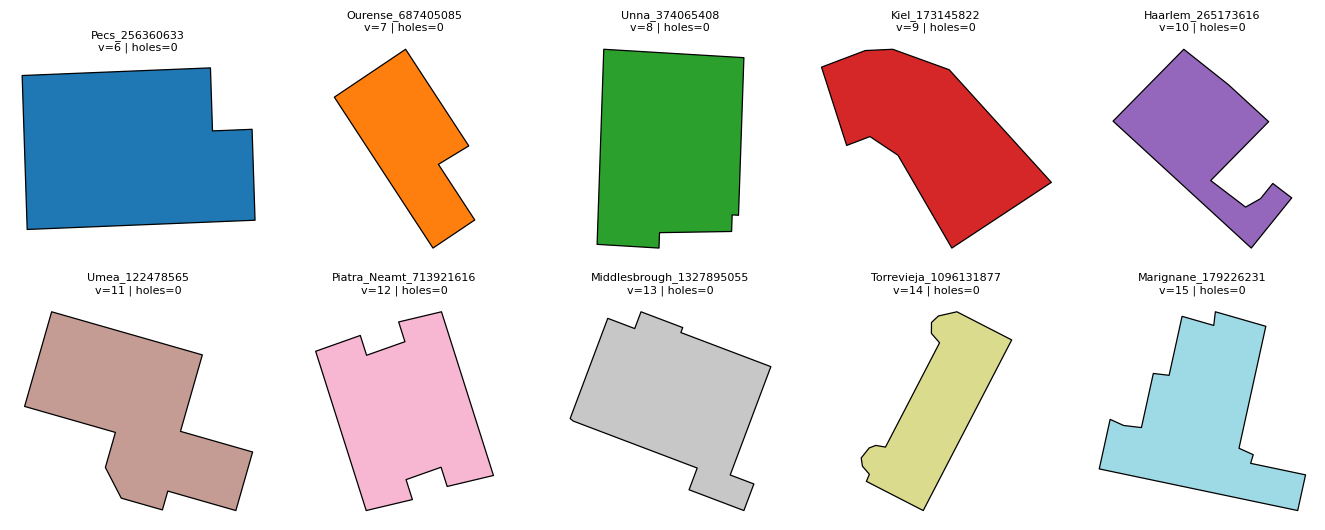

In [16]:
N_SHOW_VERTEX_BUCKETS = 10
non_empty_buckets = subset_counts_df.loc[subset_counts_df['n_selected'] > 0, 'n_vertices'].tolist()[:N_SHOW_VERTEX_BUCKETS]
subset_lookup = subset_buildings_gdf.set_index('sample_id')

if not non_empty_buckets:
    print('No non-empty vertex-count buckets to plot.')
else:
    colors = cmaps['tab20'](np.linspace(0.0, 1.0, len(non_empty_buckets)))
    subset_sources = []
    plot_ids = []
    for color, n_vertices in zip(colors, non_empty_buckets):
        g_bucket = subset_buildings_gdf.loc[subset_buildings_gdf['n_vertices'] == n_vertices].head(1).copy()
        if g_bucket.empty:
            continue
        plot_ids.extend(g_bucket['sample_id'].tolist())
        subset_sources.append({'name': f'v_{n_vertices}', 'gdf': g_bucket, 'role': 'main', 'id_col': 'sample_id', 'geometry_col': 'geometry', 'color': tuple(color), 'edgecolor': 'black', 'linewidth': 0.9})
    GHSL_gridplot(subset_sources, ids=plot_ids, ncols=min(5, len(plot_ids)), figsize_scale=2.7, title_fn=lambda sid, i: f"{sid}\nv={int(subset_lookup.loc[sid, 'n_vertices'])} | holes={int(subset_lookup.loc[sid, 'n_holes'])}")


### Prepare representative footprints across the preprocessing stages
Select three retained examples with many vertices, including at least one with holes when available, and collect the stage geometries needed for the final comparison plots.


In [17]:
N_REPRESENTATIVE_PLANS = 2
representative_ids = []

hole_candidates = subset_buildings_gdf.loc[subset_buildings_gdf['n_holes'] > 0].sort_values(['n_vertices', 'area_m2'], ascending=[False, False])
if not hole_candidates.empty:
    representative_ids.append(hole_candidates.iloc[0]['sample_id'])

for sample_id in subset_buildings_gdf.sort_values(['n_vertices', 'area_m2'], ascending=[False, False])['sample_id']:
    if sample_id not in representative_ids:
        representative_ids.append(sample_id)
    if len(representative_ids) == N_REPRESENTATIVE_PLANS:
        break

representative_df = buildings_gdf.loc[buildings_gdf['sample_id'].isin(representative_ids)].copy()
representative_df = representative_df.set_index('sample_id').loc[representative_ids].reset_index()
representative_df['stage_raw'] = representative_df['geometry_before_norm']
representative_df['stage_normalized'] = representative_df['geometry_before_align']
representative_df['stage_aligned_raw_axes'] = representative_df['geometry']
representative_df['stage_aligned_family_axes'] = representative_df['geometry']

representative_axis_rows = []
representative_axis_counts = {}
for _, row in representative_df.iterrows():
    axis_records, axis_diag = alignment_axis_records_for_polygon(row['stage_aligned_family_axes'], EDGE_ALIGNMENT_CFG)
    representative_axis_counts[row['sample_id']] = axis_diag['n_axes']
    for axis_idx, record in enumerate(axis_records):
        representative_axis_rows.append({
            'sample_id': row['sample_id'],
            'axis_idx': axis_idx,
            'family_label': f"{record['family_angle_deg']:.1f}°",
            'family_angle_deg': float(record['family_angle_deg']),
            'geometry': record['geometry'],
        })

representative_axes_gdf = gpd.GeoDataFrame(representative_axis_rows, geometry='geometry', crs=buildings_gdf.crs) if representative_axis_rows else gpd.GeoDataFrame(
    columns=['sample_id', 'axis_idx', 'family_label', 'family_angle_deg', 'geometry'], geometry='geometry', crs=buildings_gdf.crs
)

representative_df[['sample_id', 'n_vertices', 'n_holes', 'area_m2']]


,sample_id,n_vertices,n_holes,area_m2
0,Helmond_11408252,30,2,2956.431639
1,Aix_en_Provence_87167036,32,0,3395.471664


### Plot representative preprocessing stages
Show the raw, normalized, and aligned versions of the retained footprints, including the two-step axis visualization: first all inferred axes in dashed black, then the same axes colored by matched angle family.


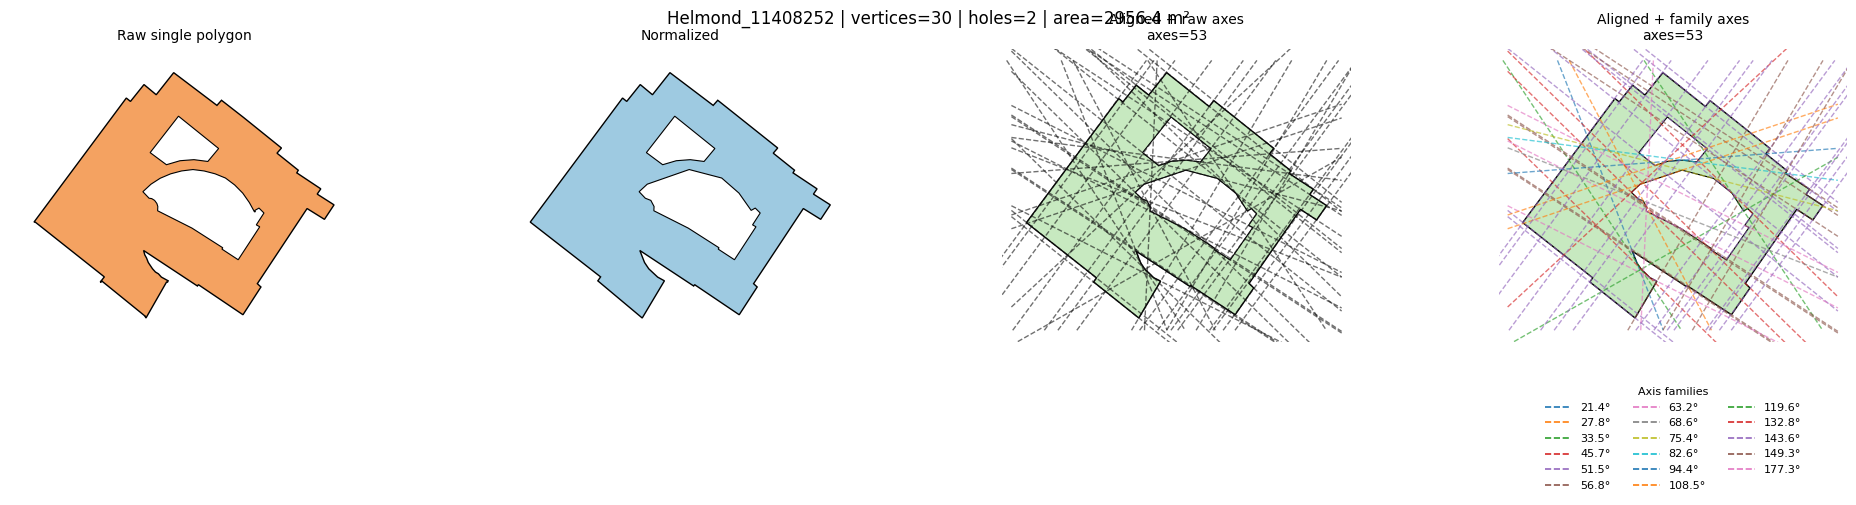

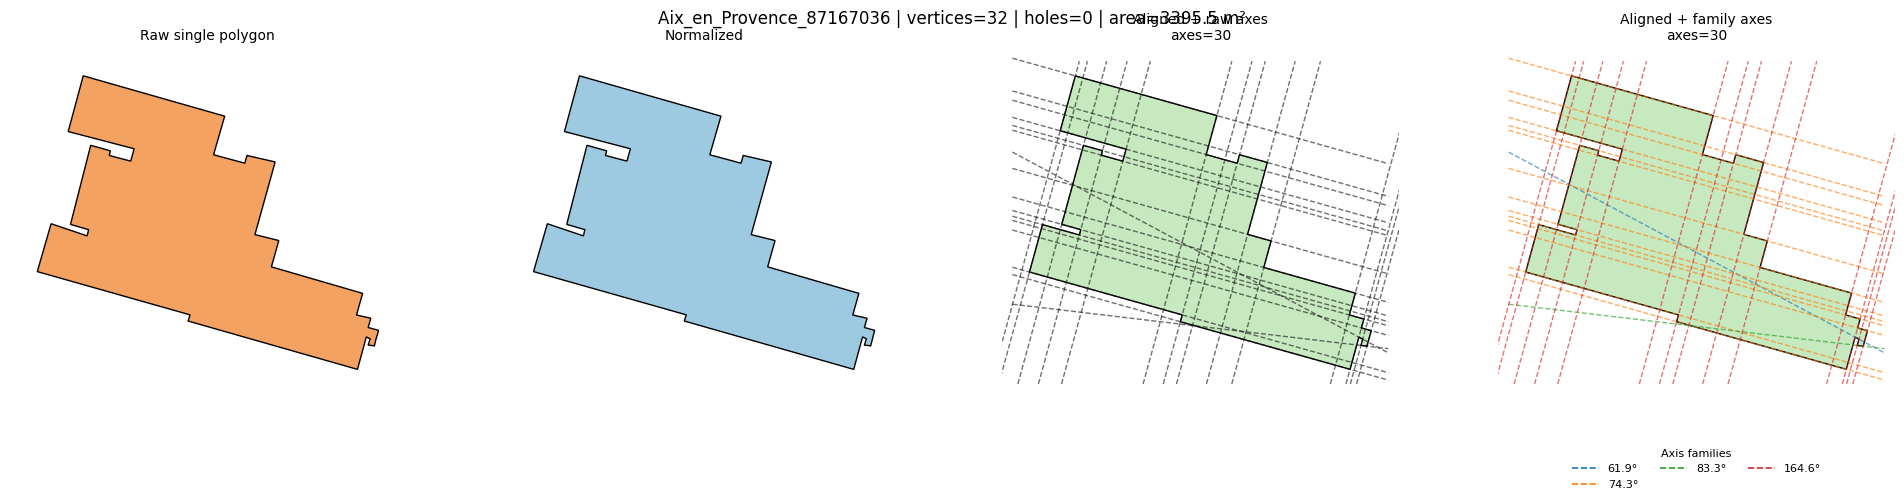

In [18]:
def _iter_polygon_parts(geom):
    if geom is None or getattr(geom, 'is_empty', True):
        return []
    if geom.geom_type == 'Polygon':
        return [geom]
    return [part for part in getattr(geom, 'geoms', []) if part is not None and not getattr(part, 'is_empty', True)]


def _plot_polygon_fill(ax, geom, facecolor, edgecolor='black', linewidth=1.0, alpha=1.0):
    for polygon in _iter_polygon_parts(geom):
        x, y = polygon.exterior.xy
        ax.fill(x, y, facecolor=facecolor, edgecolor=edgecolor, linewidth=linewidth, alpha=alpha)
        for interior in polygon.interiors:
            hx, hy = interior.xy
            ax.fill(hx, hy, facecolor='white', edgecolor=edgecolor, linewidth=0.8)


def _set_local_frame(ax, geom):
    minx, miny, maxx, maxy = geom.bounds
    span = max(maxx - minx, maxy - miny)
    pad = max(0.5, span * 0.08)
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)
    ax.set_aspect('equal')
    ax.axis('off')


stage_specs = [
    ('Raw single polygon', 'stage_raw', '#f4a261', 'none'),
    ('Normalized', 'stage_normalized', '#9ecae1', 'none'),
    ('Aligned + raw axes', 'stage_aligned_raw_axes', '#c7e9c0', 'black'),
    ('Aligned + family axes', 'stage_aligned_family_axes', '#c7e9c0', 'family'),
]

for _, row in representative_df.iterrows():
    sample_id = row['sample_id']
    fig, axes = plt.subplots(1, len(stage_specs), figsize=(5 * len(stage_specs), 4.8))
    axes = np.atleast_1d(axes)
    family_slice = representative_axes_gdf.loc[representative_axes_gdf['sample_id'] == sample_id].copy() if not representative_axes_gdf.empty else gpd.GeoDataFrame(columns=representative_axes_gdf.columns, geometry='geometry', crs=representative_axes_gdf.crs)
    family_info = family_slice[['family_label', 'family_angle_deg']].drop_duplicates().sort_values('family_angle_deg').reset_index(drop=True) if not family_slice.empty else pd.DataFrame(columns=['family_label', 'family_angle_deg'])
    family_colors = {row['family_label']: tuple(cmaps['tab10'](idx % 10)) for idx, (_, row) in enumerate(family_info.iterrows())}
    family_handles = [Line2D([0], [0], color=family_colors[label], linestyle='--', linewidth=1.2, label=label) for label in family_info['family_label']]
    for ax, (stage_title, stage_col, facecolor, axis_mode) in zip(axes, stage_specs):
        geom = row[stage_col]
        _plot_polygon_fill(ax, geom, facecolor=facecolor)
        if axis_mode == 'black' and not family_slice.empty:
            family_slice.plot(ax=ax, color='#111111', linewidth=1.0, linestyle='--', alpha=0.6, zorder=10)
        elif axis_mode == 'family' and not family_slice.empty:
            for _, family_row in family_info.iterrows():
                label = family_row['family_label']
                family_geom = family_slice.loc[family_slice['family_label'] == label]
                family_geom.plot(ax=ax, color=family_colors[label], linewidth=1.0, linestyle='--', alpha=0.65, zorder=10)
        _set_local_frame(ax, geom)
        if axis_mode == 'black':
            ax.set_title(f"{stage_title}\naxes={int(representative_axis_counts.get(sample_id, 0))}")
        elif axis_mode == 'family':
            ax.set_title(f"{stage_title}\naxes={int(representative_axis_counts.get(sample_id, 0))}")
            if family_handles:
                ax.legend(handles=family_handles, title='Axis families', loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=min(3, len(family_handles)), fontsize=8, title_fontsize=8, frameon=False, handlelength=2.4)
        else:
            ax.set_title(stage_title)
    fig.suptitle(f"{sample_id} | vertices={int(row['n_vertices'])} | holes={int(row['n_holes'])} | area={row['area_m2']:.1f} m²")
    plt.tight_layout(rect=(0, 0.03, 1, 1))
    plt.show()


### Save the preprocessed subset
Persist `subset_buildings_gdf` to `data/interim/subset_buildings_gdf.pkl` for `OSM_FloorplanDecomposition.ipynb`.

In [19]:
subset_buildings_gdf.to_pickle(SUBSET_BUILDINGS_PATH)
print('Saved subset_buildings_gdf to', SUBSET_BUILDINGS_PATH)
print('Saved exact vertex-balanced subset with up to', TARGET_PER_VERTEX, 'buildings per vertex-count bucket.')


Saved subset_buildings_gdf to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/data/interim/subset_buildings_gdf.pkl
Saved exact vertex-balanced subset with up to 1000 buildings per vertex-count bucket.


### Export preprocessed footprint figures

### Save one figure per retained preprocessed footprint

**Inputs:** `subset_buildings_gdf` after preprocessing and subset sampling

**Steps**
1. Create `output/figures/osm_preprocessed`.
2. Plot each retained footprint in its own local frame with equal aspect ratio.
3. Save one PNG per `sample_id` for manual visual inspection.

**Outputs:** `output/figures/osm_preprocessed/*.png`

**Used functions:** Matplotlib polygon plotting


In [20]:
OSM_PREPROCESSED_FIG_DIR = PROJECT_ROOT / 'output' / 'figures' / 'osm_preprocessed'
FIG_DPI = 200
FOOTPRINT_FACE_COLOR = '#4C78A8'
FOOTPRINT_EDGE_COLOR = 'black'
FOOTPRINT_LINEWIDTH = 1.0
FIG_SIZE = (4, 4)

OSM_PREPROCESSED_FIG_DIR.mkdir(parents=True, exist_ok=True)

n_exported = 0

for _, row in subset_buildings_gdf.iterrows():
    sample_id = row['sample_id']
    geom = row.geometry
    if geom is None or getattr(geom, "is_empty", True):
        continue

    fig, ax = plt.subplots(figsize=FIG_SIZE)
    polygon_parts = [geom] if geom.geom_type == 'Polygon' else list(getattr(geom, 'geoms', []))

    for polygon in polygon_parts:
        x, y = polygon.exterior.xy
        ax.fill(
            x, y,
            facecolor=FOOTPRINT_FACE_COLOR,
            edgecolor=FOOTPRINT_EDGE_COLOR,
            linewidth=FOOTPRINT_LINEWIDTH,
        )

        for interior in polygon.interiors:
            hx, hy = interior.xy
            ax.fill(hx, hy, facecolor="white", edgecolor=FOOTPRINT_EDGE_COLOR, linewidth=0.8)

    minx, miny, maxx, maxy = geom.bounds
    span = max(maxx - minx, maxy - miny)
    pad = max(0.5, span * 0.08)
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)
    ax.set_aspect('equal')
    ax.axis('off')

    out_path = OSM_PREPROCESSED_FIG_DIR / f"{sample_id}.png"
    fig.savefig(out_path, dpi=FIG_DPI, bbox_inches='tight', pad_inches=0.02)
    plt.close(fig)
    n_exported += 1

print(f'Saved {n_exported} preprocessed footprint figures to {OSM_PREPROCESSED_FIG_DIR}')


Saved 2756 preprocessed footprint figures to /Users/agatadalach/PycharmProjects/FloorplanDecompositionPaper/output/figures/osm_preprocessed


### Print a paper-ready preprocessing summary
Summarize the full OSM preprocessing pipeline with publication-ready counts derived from the raw sample, the intermediate filtered stages, and the final decomposition subset.

In [21]:
def _polygon_nonconvex_flag(geom) -> bool:
    return getattr(geom, 'geom_type', None) == 'Polygon' and not is_convex_polygon(geom)


def _fmt_pct(numerator: int | float, denominator: int | float) -> str:
    if not denominator:
        return '0.0%'
    return f"{100.0 * float(numerator) / float(denominator):.1f}%"


def _fmt_hole_counts(values: list[int]) -> str:
    if not values:
        return 'none'
    if len(values) == 1:
        return f"{values[0]} holes"
    if len(values) == 2:
        return f"{values[0]} holes and {values[1]} holes"
    return ', '.join(f"{value} holes" for value in values[:-1]) + f" and {values[-1]} holes"


def _vertex_list(df: pd.DataFrame, geometry_col: str = 'geometry') -> list[int]:
    return [int(count_exterior_vertices(geom)) for geom in df[geometry_col].tolist()]


def _nonconvex_mask(df: pd.DataFrame, geometry_col: str = 'geometry') -> pd.Series:
    return pd.Series([_polygon_nonconvex_flag(geom) for geom in df[geometry_col].tolist()], index=df.index)


raw_buildings_gdf = pd.read_pickle(BUILDINGS_GDF_PATH)
raw_total = len(raw_buildings_gdf)
raw_nonconvex_mask = _nonconvex_mask(raw_buildings_gdf)
raw_vertex_values = _vertex_list(raw_buildings_gdf)
raw_nonconvex = int(raw_nonconvex_mask.sum())
raw_vertices_total = int(sum(raw_vertex_values))
raw_vertices_median = float(np.median(raw_vertex_values)) if raw_vertex_values else 0.0
raw_nonconvex_df = raw_buildings_gdf.loc[raw_nonconvex_mask].copy()
raw_nonconvex_vertex_values = _vertex_list(raw_nonconvex_df)
raw_nonconvex_vertices_total = int(sum(raw_nonconvex_vertex_values))
raw_nonconvex_vertices_median = float(np.median(raw_nonconvex_vertex_values)) if raw_nonconvex_vertex_values else 0.0

early_discard_ids = set(discarded_multipolygon_gdf['sample_id']) | set(hard_drop_df['sample_id']) | set(too_many_holes_df['sample_id'])
stage_after_initial_df = raw_buildings_gdf.loc[~raw_buildings_gdf['sample_id'].isin(early_discard_ids)].copy()
stage_after_initial_total = len(stage_after_initial_df)
stage_after_initial_nonconvex_mask = _nonconvex_mask(stage_after_initial_df)
stage_after_initial_vertex_values = _vertex_list(stage_after_initial_df)
stage_after_initial_nonconvex = int(stage_after_initial_nonconvex_mask.sum())
stage_after_initial_vertices_total = int(sum(stage_after_initial_vertex_values))
stage_after_initial_vertices_median = float(np.median(stage_after_initial_vertex_values)) if stage_after_initial_vertex_values else 0.0
stage_after_initial_nonconvex_df = raw_nonconvex_df.loc[~raw_nonconvex_df['sample_id'].isin(early_discard_ids)].copy()
stage_after_initial_nonconvex_vertex_values = _vertex_list(stage_after_initial_nonconvex_df)
stage_after_initial_nonconvex_vertices_total = int(sum(stage_after_initial_nonconvex_vertex_values))
stage_after_initial_nonconvex_vertices_median = float(np.median(stage_after_initial_nonconvex_vertex_values)) if stage_after_initial_nonconvex_vertex_values else 0.0

final_total = len(buildings_gdf)
final_nonconvex = int((~buildings_gdf['is_convex']).sum())
final_vertices_total = int(buildings_gdf['n_vertices'].sum())
final_vertices_median = float(buildings_gdf['n_vertices'].median()) if not buildings_gdf.empty else 0.0

pre_final_aligned_df = pd.concat(
    [
        buildings_gdf,
        final_discarded_multipart_df,
        final_too_many_holes_df,
        final_already_convex_df,
        final_too_small_df,
    ],
    ignore_index=True,
    sort=False,
)
aligned_changed_nonconvex = int((
    pre_final_aligned_df['alignment_changed'].fillna(False)
    & _nonconvex_mask(pre_final_aligned_df, geometry_col='geometry_raw')
).sum())

removed_vertices_total = stage_after_initial_nonconvex_vertices_total - final_vertices_total
invalid_removed_total = int(sum(
    _nonconvex_mask(df, geometry_col='geometry_raw').sum()
    for df in [final_discarded_multipart_df, final_too_many_holes_df, final_too_small_df]
))
converted_from_nonconvex_to_convex = int(_nonconvex_mask(final_already_convex_df, geometry_col='geometry_raw').sum())
stage_after_initial_nonconvex_total = max(stage_after_initial_nonconvex, 1)

decomp_source_total = final_total
decomp_source_with_holes = int((buildings_gdf['n_holes'] > 0).sum())
decomp_source_vertices_median = float(buildings_gdf['n_vertices'].median())
subset_total = len(subset_buildings_gdf)

hole_counts_removed = sorted(too_many_holes_df['n_holes'].astype(int).tolist())

print('=== OSM preprocessing paper summary ===')
print(
    f"We had {raw_total} building footprints, from which {raw_nonconvex} were non-convex "
    f"({_fmt_pct(raw_nonconvex, raw_total)}), and {raw_vertices_total} vertices "
    f"(median {raw_vertices_median:.1f} per sample)."
)
print(
    f"We further work only with these {raw_nonconvex} non-convex footprints, with "
    f"{raw_nonconvex_vertices_total} vertices (median {raw_nonconvex_vertices_median:.1f} per sample)."
)
print(f"Discarded {len(discarded_multipolygon_gdf)} MultiPolygons of non-building artifacts.")
print(f"Discarded {len(hard_drop_df)} walls marked as buildings.")
print(
    f"Discarded {len(too_many_holes_df)} buildings with more than {MAX_ALLOWED_HOLES} holes "
    f"({_fmt_hole_counts(hole_counts_removed)})."
)
print(
    f"At this stage we have {stage_after_initial_nonconvex} non-convex buildings out of "
    f"{raw_nonconvex} ({_fmt_pct(stage_after_initial_nonconvex, raw_nonconvex)}), and "
    f"{stage_after_initial_nonconvex_vertices_total} vertices "
    f"(median {stage_after_initial_nonconvex_vertices_median:.1f} per sample)."
)
print(
    f"We do axis alignment, which influences {aligned_changed_nonconvex} / {raw_nonconvex} buildings."
)
print(
    f"After this alignment and final sanity filtering, we end up with {final_total} non-convex "
    f"({_fmt_pct(final_total, stage_after_initial_nonconvex)}), and {final_vertices_total} vertices "
    f"(median {final_vertices_median:.1f} per sample)."
)
print(
    f"This means that during the preprocessing, we removed {removed_vertices_total} vertices "
    f"({_fmt_pct(removed_vertices_total, stage_after_initial_nonconvex_vertices_total)}), "
    f"{invalid_removed_total} invalid footprints "
    f"({_fmt_pct(invalid_removed_total, stage_after_initial_total)}), and made "
    f"{converted_from_nonconvex_to_convex} earlier non-convex footprints convex "
    f"({_fmt_pct(converted_from_nonconvex_to_convex, stage_after_initial_nonconvex_total)})."
)
print(
    f"For the footprint convex decomposition, from {decomp_source_total} footprints, including "
    f"{decomp_source_with_holes} footprints with holes, with a median of "
    f"{decomp_source_vertices_median:.1f} vertices per building, we select a dataset by querying "
    f"only these non-convex footprints that have at least {VERTEX_MIN} and maximum of {VERTEX_MAX} "
    f"vertices, but with a maximum of {TARGET_PER_VERTEX} samples per number of vertices. "
    f"As larger bins have lower numbers of samples we end with {subset_total} samples for further "
    f"decomposition processing."
)


=== OSM preprocessing paper summary ===
We had 7140 building footprints, from which 3408 were non-convex (47.7%), and 50640 vertices (median 5.0 per sample).
We further work only with these 3408 non-convex footprints, with 34712 vertices (median 8.0 per sample).
Discarded 14 MultiPolygons of non-building artifacts.
Discarded 6 walls marked as buildings.
Discarded 3 buildings with more than 4 holes (6 holes, 6 holes and 9 holes).
At this stage we have 3403 non-convex buildings out of 3408 (99.9%), and 34566 vertices (median 8.0 per sample).
We do axis alignment, which influences 2876 / 3408 buildings.
After this alignment and final sanity filtering, we end up with 2895 non-convex (85.1%), and 28436 vertices (median 8.0 per sample).
This means that during the preprocessing, we removed 6130 vertices (17.7%), 2 invalid footprints (0.0%), and made 507 earlier non-convex footprints convex (14.9%).
For the footprint convex decomposition, from 2895 footprints, including 77 footprints with hole